# Encoder only for masked predictions (missing years)

* The model learns to predict both YEAR_n and event tokens.
* years are numerical and have their own embedding. 
* the main task is for prediction of the middle of the sentence

Technical notes:
* Tokens are organised such that [PAD] as ID 0,  [MASK] as ID 1, all unique events from df['event'] start from ID 2
* We prevent the model from predicting 'born' at any age ≠ 0, and mask out that prediction during training and inference by assigning logit = -Inf for "born" at any age>0.
*  **!!** only event loss is minimized (for event_ids), and not for Age (input_ages). Age is only used for the context. (The next version of this code _v5_ has age loss added for age prediction as well.)
 The model uses a BERT-style architecture where we predict *masked event* tokens based on context and the corresponding ages. The loss is computed using nn.CrossEntropyLoss between the model’s output logits (over vocabulary tokens) and the true token labels.

Specifically,
     loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1)).  Here, logits are the model's raw scores for each vocabulary token at each sequence position. labels: the ground truth event tokens (or -100 to ignore when not masked). Positions with label -100 are ignored due to how CrossEntropyLoss handles ignore_index=-100.


In [1]:
import numpy as np
import pandas as pd
import math
import random 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from torch.nn.utils.rnn import pad_sequence

import matplotlib.pyplot as plt


## Step 1: Dataset with [MASK]ed Tokens

In [2]:
# Age Positional Encoding class
class AgePositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def forward(self, age_tensor):
        B, L = age_tensor.size()
        age_tensor = age_tensor.float().unsqueeze(2)

        div_term = torch.exp(
            torch.arange(0, self.d_model, 2, dtype=torch.float32, device=age_tensor.device)
            * (-math.log(10000.0) / self.d_model)
        )
        sinusoid_input = age_tensor / div_term
        pe = torch.zeros(B, L, self.d_model, device=age_tensor.device)
        pe[:, :, 0::2] = torch.sin(sinusoid_input)
        pe[:, :, 1::2] = torch.cos(sinusoid_input)
        
        # Mask out padded positions (age == -1)
        mask = (age_tensor.squeeze(2) != -1).float().unsqueeze(2)
        pe = pe * mask
        
        return pe


In [3]:
# Dataset class
class LifeEventMaskedDataset(Dataset):
    def __init__(self, df, vocab, mask_token="[MASK]", pad_token="[PAD]", mask_prob=0.15):
        self.vocab = vocab
        self.mask_token_id = vocab[mask_token]
        self.pad_token_id = vocab[pad_token]
        self.mask_prob = mask_prob
        self.samples = []

        grouped = df.groupby('patid')
        for _, group in grouped:
            group = group.sort_values('age')
            events = []
            ages = []
            for _, row in group.iterrows():
                event_token = row['event']
                if event_token in vocab:
                    events.append(vocab[event_token])
                    ages.append(int(row['age']))
            if events:
                self.samples.append((ages, events))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ages, events = self.samples[idx]
        input_events = events.copy()
        input_ages = ages.copy()
        labels = [-100] * len(events)

        for i in range(len(events)):
            if random.random() < self.mask_prob:
                labels[i] = input_events[i]
                input_events[i] = self.mask_token_id

        return {
            "input_events": torch.tensor(input_events, dtype=torch.long),
            "input_ages": torch.tensor(input_ages, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


**labels** refer to the true token IDs that the model is expected to predict at the masked positions.

This is a BERT-style model for masked language modeling. 
That means during training:
- Some tokens in the input are randomly replaced with [MASK].
- The model is trained to predict the original tokens at those masked positions.
- All other positions (non-masked tokens) are ignored during loss computation.

In [4]:
# Custom collate function for padding
def collate_fn(batch):
    EVENT_PAD_VALUE = 0  # ID for [PAD]
    AGE_PAD_VALUE = -1 # padding value for ages 
    input_events = pad_sequence([b['input_events'] for b in batch], batch_first=True, padding_value=EVENT_PAD_VALUE)
    input_ages = pad_sequence([b['input_ages'] for b in batch], batch_first=True, padding_value=AGE_PAD_VALUE)
    labels = pad_sequence([b['labels'] for b in batch], batch_first=True, padding_value=-100)
    return {"input_events": input_events, "input_ages": input_ages, "labels": labels}


## Step 2: Encoder

In [5]:
# Transformer model with age positional encoding
class BertWithAgePE(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_seq_len=256):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.age_pe = AgePositionalEncoding(d_model=d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)

        # Set batch_first=True for easier handling of input shape
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_events, input_ages):
        B, L = input_events.shape
        pos = torch.arange(L, device=input_events.device).unsqueeze(0).expand(B, L)

        token_embed = self.token_embedding(input_events)
        age_embed = self.age_pe(input_ages)
        pos_embed = self.pos_embedding(pos)

        # Add token embedding, age positional encoding, and positional embedding
        x = token_embed + age_embed + pos_embed

        # Transformer forward 
        #x = x.transpose(0, 1)  # (L, B, D) ?
        x = self.encoder(x)  # No need for transpose since batch_first=True
        #x = x.transpose(0, 1)  # (B, L, D) ?

        return self.output_head(x)


## Step 3: Training Loop (Masked LM)

In [6]:

# Training loop
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_events = batch['input_events'].to(device)
        input_ages = batch['input_ages'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_events, input_ages)
        # Uncomment next 3 lines to skip learning at age = 0 and "born"
        # born_token_id = vocab['born']
        # mask = (input_ages != 0).unsqueeze(-1)  # shape: (B, L, 1)
        # logits[:, :, born_token_id] = logits[:, :, born_token_id].masked_fill(mask, float('-inf'))

        loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


## Step 4: Inference — Fill Masked Token


In [7]:
def predict_masked(model, input_events, input_ages, vocab, id_to_token, device):
    model.eval()
    input_events_tensor = torch.tensor(input_events, dtype=torch.long).unsqueeze(0).to(device)
    input_ages_tensor = torch.tensor(input_ages, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_events_tensor, input_ages_tensor)

        # Restrict 'born' prediction to age == 0 and suppress [PAD]/[MASK]
        born_token_id = vocab['born']
        pad_token_id = vocab['[PAD]']
        mask_token_id = vocab['[MASK]']
        mask_indices = (input_events_tensor == mask_token_id)
        print (mask_token_id)
        for b in range(logits.size(0)):
            for i in range(logits.size(1)):
                if mask_indices[b, i]:
                    logits[b, i, pad_token_id] = -float('inf')
                    logits[b, i, mask_token_id] = -float('inf')
                    if input_ages_tensor[b, i] != 0:
                        logits[b, i, born_token_id] = -float('inf')

        probs = F.softmax(logits, dim=-1)  # (1, L, vocab_size)
    
    # old version: return most probable token
    #   predictions = torch.argmax(probs, dim=-1)
    #  return [id_to_token[t.item()] for t in predictions[0]]
    
    # Build a DataFrame with full probability vector for each MASK
    results = []
    for i, token_id in enumerate(input_events):
        if token_id == mask_token_id:
            prob_vector = probs[0, i].cpu().numpy()
            prob_dict = {id_to_token[j]: float(prob_vector[j]) for j in range(2,len(prob_vector))}
            results.append({
                "position": i,
                "age": input_ages[i],
                "probabilities": prob_dict
            })

    return pd.DataFrame(results)



In [96]:
def plot_mask_token_distributions(res, n_plots=1):
    probabilities_dict= res.probabilities
    mask_indices = list(probabilities_dict.keys())[:n_plots]  # First 4 MASK positions    
    fig, axes = plt.subplots(2, n_plots//2 , figsize=(14, 6))        
    for idx, mask_pos in enumerate(mask_indices):
            row, col = divmod(idx, 2)
            ax = axes[row][col]    
            token_probs = pd.Series(probabilities_dict[mask_pos]).sort_values(ascending=False)
            token_probs.plot.bar(ax=ax)
            ax.set_title(f"MASK at position {mask_pos}")
            ax.set_ylabel("Probability")
            ax.set_xlabel("Token")
            ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [100]:
list(result.probabilities.keys())

[0, 1, 2]

## Step 5: Implementation with toy data

In [36]:
# read training data, create main main_vocab from all events in the data, create year_main_vocab from 0 to 110
df = pd.read_csv("Event_data.csv")
# create main_vocabulary from all diff words in df.event

unique_events = sorted(df['event'].unique())
vocab = {'[PAD]': 0, '[MASK]': 1}
for i, event in enumerate(unique_events, start=2):
    vocab[event] = i
    id_to_token = {v: k for k, v in vocab.items()}
#id_to_token = {idx: token for token, idx in vocab.items()}

# '[PAD]': 0, '[MASK]': 1, 'born': 2,  'cancer': 3, 'died': 4, 'flu': 5, 't2dm': 6

In [9]:
# --- Hyperparameters ---
batch_size = 3
num_epochs = 100
lr = 1e-4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#  pad_token_id = 0  # You must ensure this ID is reserved for padding in your main_vocab
# ! we dont need this in encoder?

In [10]:
# --- Dataset and DataLoader ---
dataset = LifeEventMaskedDataset(df, vocab)
dataloader = DataLoader(dataset, batch_size=3, shuffle=True, collate_fn = collate_fn)

In [21]:
#del(model)
# --- Model, Loss, Optimizer ---
model = BertWithAgePE(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index = -100)

In [30]:
# --- Training Loop ---
for epoch in range(num_epochs):
    loss = train(model, dataloader, optimizer, criterion, 'cpu')
    if (epoch <= 10): 
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")
    else:
        if (epoch%10 == 0):
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")

Epoch 1/100 | Loss: 0.0232
Epoch 2/100 | Loss: 0.0513
Epoch 3/100 | Loss: nan
Epoch 4/100 | Loss: nan
Epoch 5/100 | Loss: 0.0455
Epoch 6/100 | Loss: nan
Epoch 7/100 | Loss: 0.0526
Epoch 8/100 | Loss: nan
Epoch 9/100 | Loss: 0.1945
Epoch 10/100 | Loss: nan
Epoch 11/100 | Loss: 0.0414
Epoch 21/100 | Loss: 0.0212
Epoch 31/100 | Loss: 0.0381
Epoch 41/100 | Loss: 0.0125
Epoch 51/100 | Loss: nan
Epoch 61/100 | Loss: nan
Epoch 71/100 | Loss: nan
Epoch 81/100 | Loss: nan
Epoch 91/100 | Loss: nan


In [61]:
# Example inference
input_events = ["born", "[MASK]", "died"]
masked_ages = [0, 28, 45]
masked_input_events = [vocab[e] for e in input_events] # 'born [MASK] died'   -> into tokens [2,1,4] 

result = predict_masked(model, masked_input_events, masked_ages, vocab, id_to_token, device)
result

1


,position,age,probabilities
0,1,28,"{'born': 0.0, 'cancer': 0.0007369656232185662,..."


In [68]:
# Example inference
input_events = ["born", "[MASK]" , "cancer", "[MASK]", "t2dm", "[MASK]"]  # 'born [MASK] died'  
masked_ages = [0, 28, 45, 65, 70, 80]

masked_input_events = [vocab[e] for e in input_events] # 'born [MASK] died'   -> into tokens [2,1,4] 

result = predict_masked(model, masked_input_events, masked_ages, vocab, id_to_token, device)
result

1


,position,age,probabilities
0,1,28,"{'born': 0.0, 'cancer': 0.010458198375999928, ..."
1,3,65,"{'born': 0.0, 'cancer': 0.2179747223854065, 'd..."
2,5,80,"{'born': 0.0, 'cancer': 0.006944275461137295, ..."


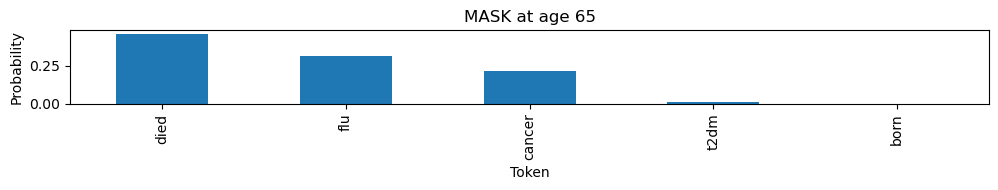

(Text(24.000000000000007, 0.5, 'Probability'),
 Text(0.5, 24.0, 'Token'),
 None,
 None)

In [103]:
# Histogram for the probabilities over all possible events for MASK positions
probs1 = result.probabilities[0]
probs2 = result.probabilities[1]
pd.Series(probs2).sort_values(ascending=False).plot.bar(figsize=(10, 2), title=f"MASK at age {result.age[1]}")
plt.ylabel("Probability"), plt.xlabel("Token"), plt.tight_layout(), plt.show()

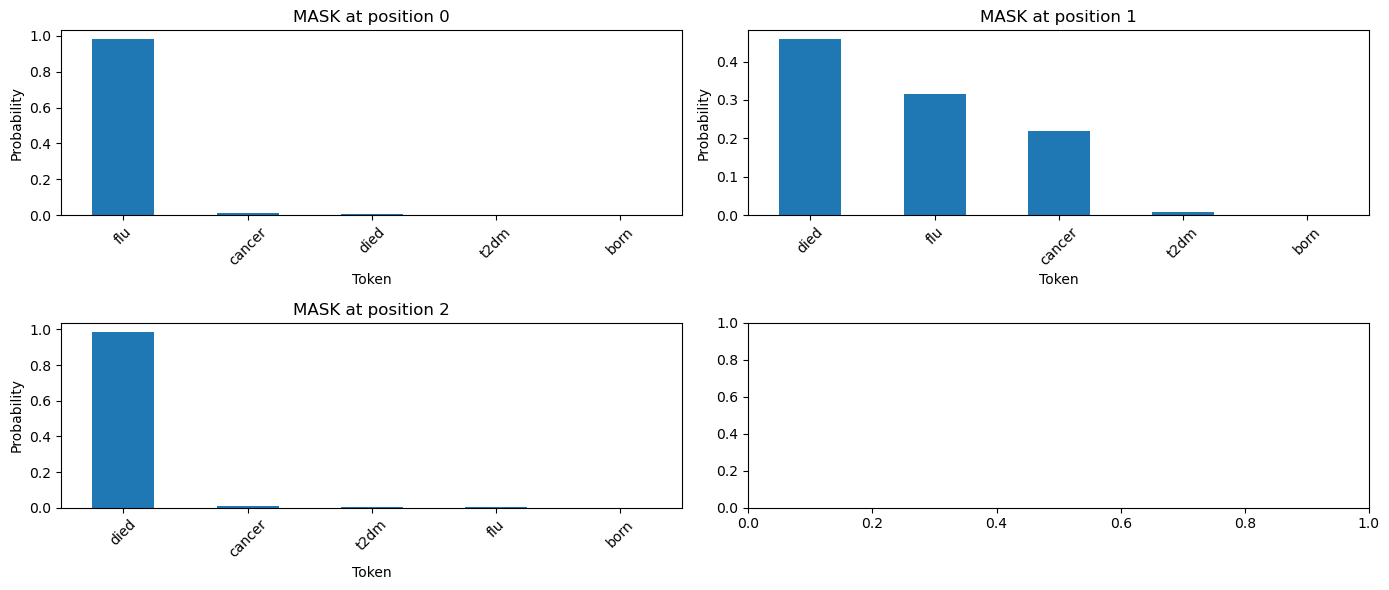

In [97]:
plot_mask_token_distributions(result, 4)

In [99]:
result.age

,position,age,probabilities
0,1,28,"{'born': 0.0, 'cancer': 0.010458198375999928, ..."
1,3,65,"{'born': 0.0, 'cancer': 0.2179747223854065, 'd..."
2,5,80,"{'born': 0.0, 'cancer': 0.006944275461137295, ..."
